# <center><b>Computational Essay "Native Sparce Attention"</b></center>

# Большаковой Аллы Глебовны

В статье предлагается метод "Native Sparce Attetion" или разреженное внимание. "Native Sparce Attetion" - это механизм для ускорения блока внимания в нейросети. Согласно статье, по оценке качества он совпадает с Full Attention, а по скорости имеет преимущество в несколько раз, причем проявляется это на длинных последовательностях токенов. (рис.1)

Дело в том, что в языковой модели работа Attention делится на два этапа: prefilling и decoding. Prefilling - загрузка промпта в модель, тут тратится много вычислительных ресурсов, так как для всей длины промпта нужно просчитать Attention. Далее матрицы сохраняются и на шаге Decoding начинается их применение и формирование ответа модели. На этом этапе огромные матрицы K и V загружаются в память и тратится много ресурса памяти. То есть на разных этапах разные ограничения. Хотелось бы Attention, который бы мог одинаково эффективно справляться и с Prefilling, и с Decoding. Это и есть Native Sparce Attetion.

В статье также обсуждаются некоторые уже существующие методы по оптимизации Attention, такие как Group Query Attention (Q делятся на блоки и к каждому блоку применяются свои K и V) и Multi Query Attention (одинаковые K и V для всех Q). Однако они сокращают или затраты по памяти, или затраты по вычислительным ресурсам, но не оба сразу. Поэтому и был предложен Native Sparce Attetion.

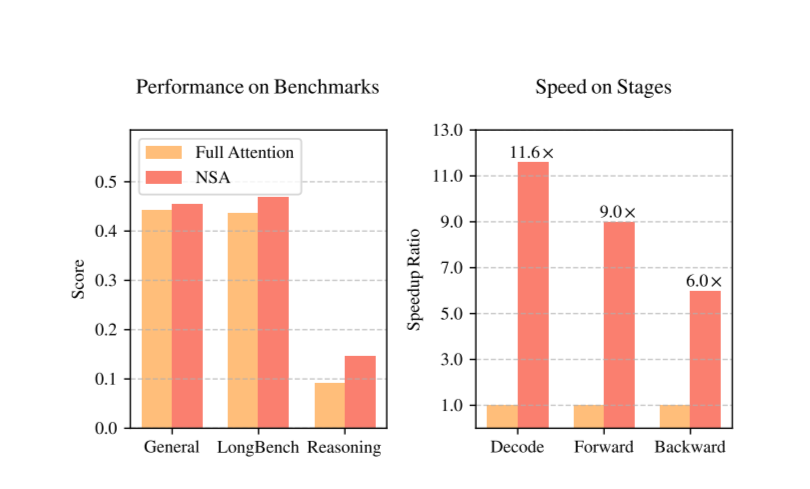

Формула для Attention такая: $$o_t = Attn(q_t, k_{:t}, v_{:t})$$

Здесь Attn это:

$$\text{Attn}(q_t, k, v) = \frac{\sum_{i=1}^{t} \alpha_{t,i} v_i}{\sum_{j=1}^{t} \alpha_{t,j}}, \quad \alpha_{t,i} = \frac{q_t^\top k_i}{\sqrt{d_k}}$$


В NSA три основных этапа: Compressed Attention, Selected Attention и Sliding Window. (рис. 2) Compressed Attention - это этап, когда Attention применяется поблочно к набору токенов, то есть от каждого блока токенов считаются некоторые функции:

$$\tilde{K}_t = f_K(q_t, k_{:t}, v_{:t}), \quad \tilde{V}_t = f_V(q_t, k_{:t}, v_{:t})$$

И затем Attention применяется к ним:

$$o_t^* = \text{Attn}(q_t, \tilde{K}_t, \tilde{V}_t)$$

В NSA $\tilde{K}_t$ и $\tilde{V}_t$ определяются как:

$$\tilde{K}_{\text{cmp}}^t = f_{\text{cmp}}^K(k_{:t}) = \{ \phi(k_{id+1:id+l}) \}_{0 \le i \le \frac{t-l}{d}}$$,

то есть функция идет от непрерывного блока токенов, где l - длина группы.


Далее методом Softmax выбираются top-n лучших групп токенов:

$$p_{\text{cmp}}^t = \text{Softmax}(q_t^\top \tilde{K}_{\text{cmp}}^t)$$

Затем лучшие блоки ранжируют:

$$I_t = \{ i \mid \text{rank}(\text{pslc}_t'[i]) \leq n \}$$

Собирают в единую матрицу:

$$\tilde{K}_{\text{slc},t} = \text{Cat}\, \{ k_{i\ell'+1:(i+1)\ell'} \mid i \in I_t \}$$


И для каждого из них считает обычный Attention.

Третий этап это Sliding Window или скользящее окно. Этот этап нужен для захвата контекста из соседних токенов.





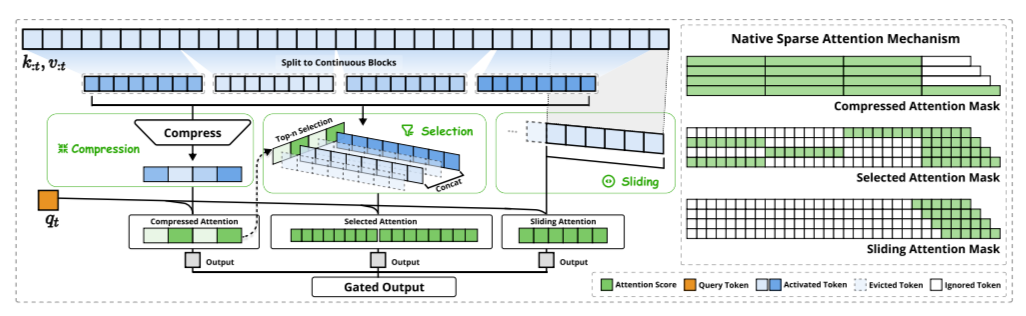

Также был предложен новый дизайн ядра на базе языка Triton - языка для написания оптимизированного кода на GPU. (рис 3)

В ядрах используются принципы GQA и MQA. То ксть Q делятся на блоки с одинаковыми K и V и далее для каждой группы загружются K и V и применяются сразу для всех необходимых значений Q.

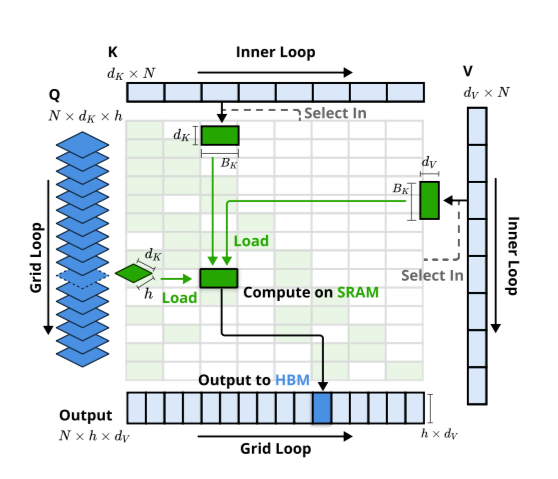

Ниже представлен код для моей реализации NSA.
В начале я делала NSA на Pytorch, но оказалось, что для длинных последовательностей токенов не хватает памяти встроенного в Colab GPU. Поэтому еще ниже был написан NSA с использованием оптимизатора Triton.

# NSA на чистом Pytorch

In [ ]:
import time
import torch.nn.functional as F
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class TokenCompression(nn.Module):
    def __init__(self, d_k, block_len):
        super().__init__()
        self.block_len = block_len
        self.compressor = nn.Sequential(
            nn.Linear(block_len * d_k, d_k),
            nn.GELU(),
            nn.Linear(d_k, d_k)
        )

    def forward(self, x):
        # x: [B, H, T, d_k]
        B, H, T, d_k = x.shape
        pad_len = (self.block_len - (T % self.block_len)) % self.block_len
        if pad_len > 0:
            x = F.pad(x, (0, 0, 0, pad_len))

        T_padded = x.shape[2]
        num_blocks = T_padded // self.block_len # Делаим общую длину на длину блоков

        x_blocked = x.reshape(B, H, num_blocks, self.block_len * d_k)
        compressed = self.compressor(x_blocked) # [B, H, num_blocks, d_k], сжатие для каждого блока
        return compressed

class NativeSparseAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_len=32, top_n=4, window_size=128):
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_k = d_model // n_heads
        self.block_len = block_len
        self.top_n = top_n
        self.window_size = window_size

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.k_compressor = TokenCompression(self.d_k, block_len) # Компрессоры для К и V
        self.v_compressor = TokenCompression(self.d_k, block_len)

        self.gate_mlp = nn.Linear(d_model, 3) # Шлюз гейт, выбирает какая из ветвей важнее

    def _scaled_dot_product_attn(self, q, k, v, mask=None): # Вычисление Attention
        scale = q.size(-1) ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(scores, dim=-1)
        return torch.matmul(attn_weights, v), attn_weights

    def forward(self, x):
        B, T, C = x.shape
        H = self.n_heads

        q = self.q_proj(x).view(B, T, H, self.d_k).transpose(1, 2).contiguous()
        k = self.k_proj(x).view(B, T, H, self.d_k).transpose(1, 2).contiguous()
        v = self.v_proj(x).view(B, T, H, self.d_k).transpose(1, 2).contiguous()

        # Ветвь 1 Сжатое внимание
        k_cmp = self.k_compressor(k)
        v_cmp = self.v_compressor(v)
        out_cmp, attn_cmp = self._scaled_dot_product_attn(q, k_cmp, v_cmp)

        # Ветвь 2 Выборочное внимание
        _, top_block_indices = torch.topk(attn_cmp, k=self.top_n, dim=-1) # [B, H, T, top_n]

        pad_len = (self.block_len - (T % self.block_len)) % self.block_len
        k_padded = F.pad(k, (0, 0, 0, pad_len)) if pad_len > 0 else k
        v_padded = F.pad(v, (0, 0, 0, pad_len)) if pad_len > 0 else v

        block_offsets = torch.arange(self.block_len, device=x.device)
        token_indices = top_block_indices.unsqueeze(-1) * self.block_len + block_offsets
        token_indices = token_indices.flatten(start_dim=3) # [B, H, T, top_n * block_len]

        # Сдвиг для каждого батча и головы: [B, H, 1, 1]
        batch_head_stride = (torch.arange(B * H, device=x.device).view(B, H, 1, 1) * k_padded.shape[2])

        # Сплющиваем K и V до [B * H * T_padded, d_k]
        k_flat = k_padded.reshape(-1, self.d_k)
        v_flat = v_padded.reshape(-1, self.d_k)

        # Добавляем смещения батча/головы к индексам токенов
        flat_indices = token_indices + batch_head_stride
        flat_indices = flat_indices.flatten() # [B * H * T * top_n * block_len]

        # Извлекаем токены
        sk = k_flat[flat_indices].view(B, H, T, self.top_n * self.block_len, self.d_k)
        sv = v_flat[flat_indices].view(B, H, T, self.top_n * self.block_len, self.d_k)

        # Считаем внимание выбранной ветви
        q_uns = q.unsqueeze(-2)
        scores_slc = torch.matmul(q_uns, sk.transpose(-1, -2)) * (self.d_k ** -0.5)
        attn_slc = F.softmax(scores_slc, dim=-1)
        out_slc = torch.matmul(attn_slc, sv).squeeze(-2)

        # Ветвь 3 Скользящее окно
        mask_win = torch.tril(torch.ones(T, T, device=x.device))
        mask_win = mask_win * torch.triu(torch.ones(T, T, device=x.device), diagonal=-self.window_size)
        out_win, _ = self._scaled_dot_product_attn(q, k, v, mask=mask_win)

        # Подсчет весов гейтов
        gates = F.softmax(self.gate_mlp(x), dim=-1)
        gate_cmp = gates[..., 0].view(B, 1, T, 1)
        gate_slc = gates[..., 1].view(B, 1, T, 1)
        gate_win = gates[..., 2].view(B, 1, T, 1)

        out = gate_cmp * out_cmp + gate_slc * out_slc + gate_win * out_win
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.out_proj(out)

# Проверка совпадения размерностей

In [ ]:
if __name__ == "__main__":
    B, T, d_model, n_heads = 2, 256, 128, 4 # B - число текстов, T - число токенов, d_model - размерность токена, n_heads - число голов
    x = torch.randn(B, T, d_model)
    nsa = NativeSparseAttention(d_model=d_model, n_heads=n_heads, block_len=32, top_n=2, window_size=64)
    output = nsa(x)
    print("Выходной тензор:", output.shape)

Выходной тензор: torch.Size([2, 256, 128])


# Тест на коротких последовательностях токенов

In [ ]:
# Тест
def benchmark_attention():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    B = 2
    d_model = 256
    n_heads = 4

    # Разные длины контекста для тестирования
    context_lengths = [256, 512, 1024, 2048, 4096]

    # Инициализация моделей
    nsa_model = NativeSparseAttention(
        d_model=d_model,
        n_heads=n_heads,
        block_len=32,
        top_n=2,
        window_size=128
    ).to(device)

    standard_attn = nn.MultiheadAttention(
        embed_dim=d_model,
        num_heads=n_heads,
        batch_first=True
    ).to(device)

    results = {
        "lengths": context_lengths,
        "standard_fwd": [], "standard_bwd": [],
        "nsa_fwd": [], "nsa_bwd": []
    }

    warmup_steps = 3
    num_steps = 10

    for T in context_lengths:
        x = torch.randn(B, T, d_model, device=device, requires_grad=True)
        grad_output = torch.randn(B, T, d_model, device=device)

        # Обычный Multihead
        for _ in range(warmup_steps):
            out, _ = standard_attn(x, x, x)
            out.backward(grad_output, retain_graph=True)
            standard_attn.zero_grad()
            if x.grad is not None: x.grad.zero_()

        if device.type == "cuda": torch.cuda.synchronize()

        # Forward
        start_time = time.time()
        for _ in range(num_steps):
            out, _ = standard_attn(x, x, x)
        if device.type == "cuda": torch.cuda.synchronize()
        std_fwd_time = (time.time() - start_time) / num_steps

        #Backward
        start_time = time.time()
        for _ in range(num_steps):
            out.backward(grad_output, retain_graph=True)
        if device.type == "cuda": torch.cuda.synchronize()
        std_bwd_time = (time.time() - start_time) / num_steps

        results["standard_fwd"].append(std_fwd_time * 1000)
        results["standard_bwd"].append(std_bwd_time * 1000)

        standard_attn.zero_grad()
        if x.grad is not None: x.grad.zero_()

        # NSA
        for _ in range(warmup_steps):
            out = nsa_model(x)
            out.backward(grad_output, retain_graph=True)
            nsa_model.zero_grad()
            if x.grad is not None: x.grad.zero_()

        if device.type == "cuda": torch.cuda.synchronize()

        # Forward
        start_time = time.time()
        for _ in range(num_steps):
            out = nsa_model(x)
        if device.type == "cuda": torch.cuda.synchronize()
        nsa_fwd_time = (time.time() - start_time) / num_steps

        # Backward
        start_time = time.time()
        for _ in range(num_steps):
            out.backward(grad_output, retain_graph=True)
        if device.type == "cuda": torch.cuda.synchronize()
        nsa_bwd_time = (time.time() - start_time) / num_steps

        results["nsa_fwd"].append(nsa_fwd_time * 1000)
        results["nsa_bwd"].append(nsa_bwd_time * 1000)

        nsa_model.zero_grad()
        if x.grad is not None: x.grad.zero_()

        print(f"Standard Attn -> Forward: {std_fwd_time*1000:.2f}ms | Backward: {std_bwd_time*1000:.2f}ms")
        print(f"NSA Attention -> Forward: {nsa_fwd_time*1000:.2f}ms | Backward: {nsa_bwd_time*1000:.2f}ms\n")

    return results


In [ ]:
if __name__ == "__main__":
    benchmark_results = benchmark_attention()

Standard Attn -> Forward: 0.47ms | Backward: 1.04ms
NSA Attention -> Forward: 2.09ms | Backward: 4.63ms

Standard Attn -> Forward: 0.93ms | Backward: 2.00ms
NSA Attention -> Forward: 4.15ms | Backward: 8.65ms

Standard Attn -> Forward: 1.52ms | Backward: 3.01ms
NSA Attention -> Forward: 6.03ms | Backward: 11.24ms

Standard Attn -> Forward: 5.29ms | Backward: 10.00ms
NSA Attention -> Forward: 15.66ms | Backward: 27.72ms

Standard Attn -> Forward: 19.38ms | Backward: 34.75ms
NSA Attention -> Forward: 47.08ms | Backward: 75.43ms



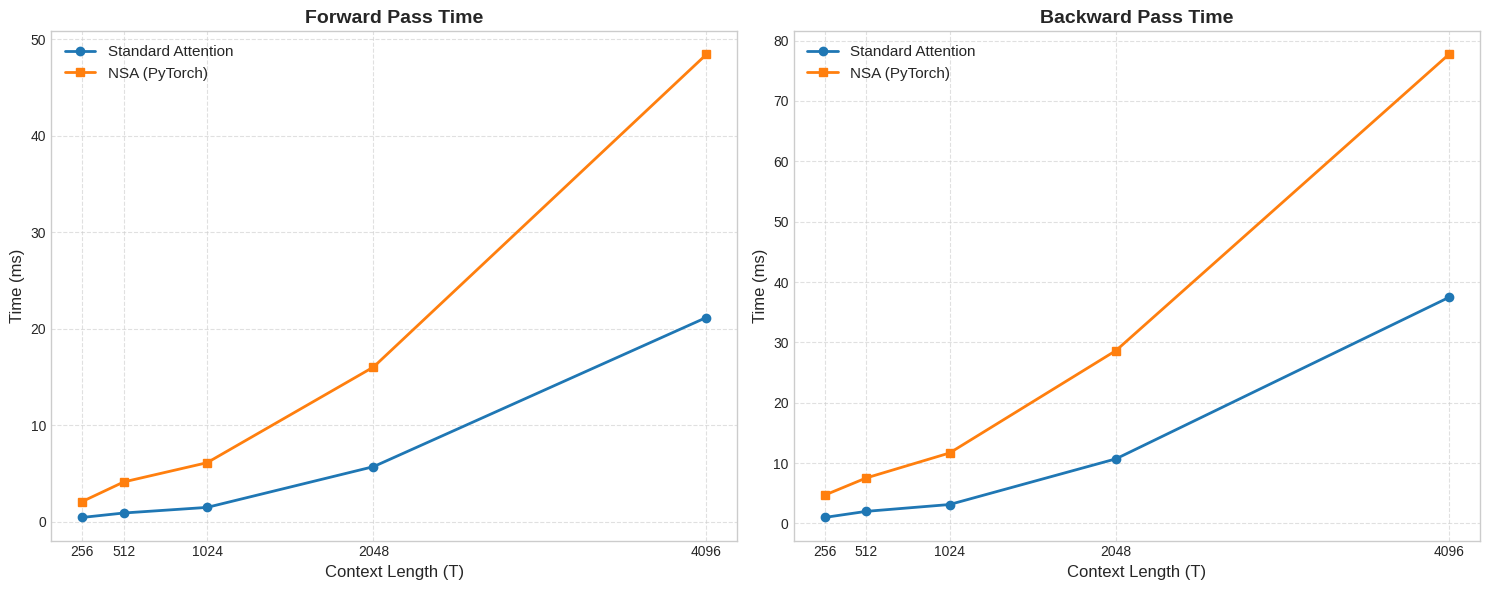

In [ ]:
lengths = [256, 512, 1024, 2048, 4096]

std_fwd = [0.47, 0.93, 1.51, 5.73, 21.18]
nsa_fwd = [2.12, 4.15, 6.14, 16.05, 48.43]

std_bwd = [0.99, 2.00, 3.13, 10.70, 37.44]
nsa_bwd = [4.69, 7.54, 11.67, 28.64, 77.70]

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Forward Pass
ax1.plot(lengths, std_fwd, label='Standard Attention', marker='o', linewidth=2, color='#1f77b4')
ax1.plot(lengths, nsa_fwd, label='NSA (PyTorch)', marker='s', linewidth=2, color='#ff7f0e')
ax1.set_title('Forward Pass Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Context Length (T)', fontsize=12)
ax1.set_ylabel('Time (ms)', fontsize=12)
ax1.set_xticks(lengths)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=11)

# Backward Pass
ax2.plot(lengths, std_bwd, label='Standard Attention', marker='o', linewidth=2, color='#1f77b4')
ax2.plot(lengths, nsa_bwd, label='NSA (PyTorch)', marker='s', linewidth=2, color='#ff7f0e')
ax2.set_title('Backward Pass Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Context Length (T)', fontsize=12)
ax2.set_ylabel('Time (ms)', fontsize=12)
ax2.set_xticks(lengths)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


**Вывод**: пока эксперимент только для маленьких длин. Да, пока NSA медленнее, чем обычный Attention, но уже заметно, что при увеличении длины последовательности вдвое с 2048 до 4096 время выполнения обычного Attention увеличивается в 4 раза, то квадратично.  А время выполнения NSA увеличивается в $\sim$ 3 раза.

# NSA с использованием Triton

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import triton
import triton.language as tl

# 1. Triton ядро
@triton.jit
def _sliding_window_fwd_kernel(
    Q_ptr, K_ptr, V_ptr, Out_ptr,
    stride_qb, stride_qh, stride_qt, stride_qd,
    stride_kb, stride_kh, stride_kt, stride_kd,
    stride_vb, stride_vh, stride_vt, stride_vd,
    stride_ob, stride_oh, stride_ot, stride_od,
    Z, H, T,
    WINDOW_SIZE,
    d_k: tl.constexpr,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr
):
    start_m = tl.program_id(0)
    off_h = tl.program_id(1)
    off_b = tl.program_id(2)

    if start_m * BLOCK_M >= T:
        return

    q_offset = off_b * stride_qb + off_h * stride_qh
    k_offset = off_b * stride_kb + off_h * stride_kh
    v_offset = off_b * stride_vb + off_h * stride_vh
    o_offset = off_b * stride_ob + off_h * stride_oh

    offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_d = tl.arange(0, d_k)

    # Загружаем Q: [BLOCK_M, d_k]
    q_ptrs = Q_ptr + q_offset + offs_m[:, None] * stride_qt + offs_d[None, :] * stride_qd
    q_mask = (offs_m[:, None] < T) & (offs_d[None, :] < d_k)
    q = tl.load(q_ptrs, mask=q_mask, other=0.0)

    scale = 1.0 / (d_k ** 0.5)

    start_n = max(0, (start_m * BLOCK_M - WINDOW_SIZE) // BLOCK_N * BLOCK_N)
    end_n = min(T, (start_m + 1) * BLOCK_M)

    acc = tl.zeros((BLOCK_M, d_k), dtype=tl.float32)
    m_i = tl.full((BLOCK_M,), float("-inf"), dtype=tl.float32)
    l_i = tl.zeros((BLOCK_M,), dtype=tl.float32)

    for start_n_idx in range(start_n, end_n, BLOCK_N):
        offs_n = start_n_idx + tl.arange(0, BLOCK_N)

        # Загружаем K: [d_k, BLOCK_N]
        k_ptrs = K_ptr + k_offset + offs_d[:, None] * stride_kd + offs_n[None, :] * stride_kt
        k_mask = (offs_d[:, None] < d_k) & (offs_n[None, :] < T)
        k = tl.load(k_ptrs, mask=k_mask, other=0.0)

        # Загружаем V: [BLOCK_N, d_k]
        v_ptrs = V_ptr + v_offset + offs_n[:, None] * stride_vt + offs_d[None, :] * stride_vd
        v_mask = (offs_n[:, None] < T) & (offs_d[None, :] < d_k)
        v = tl.load(v_ptrs, mask=v_mask, other=0.0)

        # Перемножение матриц
        qk = tl.dot(q, k) * scale

        # Маскирование
        mask = (offs_m[:, None] >= offs_n[None, :]) & \
               (offs_m[:, None] - offs_n[None, :] <= WINDOW_SIZE) & \
               (offs_n[None, :] < T) & (offs_m[:, None] < T)

        qk = tl.where(mask, qk, float("-inf"))

        # Softmax
        m_ij = tl.max(qk, axis=1)
        p = tl.exp(qk - m_ij[:, None])
        l_ij = tl.sum(p, axis=1)

        m_next = tl.maximum(m_i, m_ij)
        alpha = tl.exp(m_i - m_next)
        beta = tl.exp(m_ij - m_next)

        l_i = l_i * alpha + l_ij * beta
        acc = acc * alpha[:, None] + tl.dot(p.to(tl.float16), v) * beta[:, None]
        m_i = m_next

    l_i_safe = tl.where(l_i > 0, l_i, 1.0)
    acc = acc / l_i_safe[:, None]

    out_ptrs = Out_ptr + o_offset + offs_m[:, None] * stride_ot + offs_d[None, :] * stride_od
    out_mask = (offs_m[:, None] < T) & (offs_d[None, :] < d_k)

    tl.store(out_ptrs, acc.to(tl.float16), mask=out_mask)

class TritonSlidingWindowAttention(nn.Module):
    def __init__(self, window_size=128):
        super().__init__()
        self.window_size = window_size

    def forward(self, q, k, v):
        q, k, v = q.half(), k.half(), v.half()
        B, H, T, d_k = q.shape
        out = torch.empty_like(q)

        BLOCK_M = 32
        BLOCK_N = 32
        grid = (triton.cdiv(T, BLOCK_M), H, B)

        _sliding_window_fwd_kernel[grid](
            q, k, v, out,
            q.stride(0), q.stride(1), q.stride(2), q.stride(3),
            k.stride(0), k.stride(1), k.stride(2), k.stride(3),
            v.stride(0), v.stride(1), v.stride(2), v.stride(3),
            out.stride(0), out.stride(1), out.stride(2), out.stride(3),
            B, H, T,
            self.window_size,
            d_k=d_k,
            BLOCK_M=BLOCK_M,
            BLOCK_N=BLOCK_N,
            num_warps=4, num_stages=2
        )
        return out



# 2. Модкль сжатия токенов
class TokenCompression(nn.Module):
    def __init__(self, d_k, block_len):
        super().__init__()
        self.block_len = block_len
        self.compressor = nn.Sequential(
            nn.Linear(block_len * d_k, d_k),
            nn.GELU(),
            nn.Linear(d_k, d_k)
        )

    def forward(self, x):
        B, H, T, d_k = x.shape
        pad_len = (self.block_len - (T % self.block_len)) % self.block_len
        if pad_len > 0:
            x = F.pad(x, (0, 0, 0, pad_len))

        num_blocks = x.shape[2] // self.block_len
        x_blocked = x.reshape(B, H, num_blocks, self.block_len * d_k)
        compressed = self.compressor(x_blocked)
        return compressed

# 3. NSA
class NativeSparseAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_len=32, top_n=4, window_size=128):
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_k = d_model // n_heads
        self.block_len = block_len
        self.top_n = top_n

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        # Ветви
        self.k_compressor = TokenCompression(self.d_k, block_len)
        self.v_compressor = TokenCompression(self.d_k, block_len)
        self.sliding_window_triton = TritonSlidingWindowAttention(window_size=window_size)

        # Гейты
        self.gate_mlp = nn.Linear(d_model, 3)

    def _scaled_dot_product_attn(self, q, k, v, mask=None):
        scale = q.size(-1) ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(scores, dim=-1)
        return torch.matmul(attn_weights, v), attn_weights

    def forward(self, x):
        x = x.to(dtype=self.q_proj.weight.dtype)

        B, T, C = x.shape
        H = self.n_heads

        # Вычисляем Q, K, V
        q = self.q_proj(x).view(B, T, H, self.d_k).transpose(1, 2).contiguous()
        k = self.k_proj(x).view(B, T, H, self.d_k).transpose(1, 2).contiguous()
        v = self.v_proj(x).view(B, T, H, self.d_k).transpose(1, 2).contiguous()

        # Ветвь 1 Compressed Attention
        k_cmp = self.k_compressor(k)
        v_cmp = self.v_compressor(v)
        out_cmp, attn_cmp = self._scaled_dot_product_attn(q, k_cmp, v_cmp)

        # Ветвь 2 Selected Attention
        _, top_block_indices = torch.topk(attn_cmp.float(), k=self.top_n, dim=-1)

        pad_len = (self.block_len - (T % self.block_len)) % self.block_len
        k_padded = F.pad(k, (0, 0, 0, pad_len)) if pad_len > 0 else k
        v_padded = F.pad(v, (0, 0, 0, pad_len)) if pad_len > 0 else v

        block_offsets = torch.arange(self.block_len, device=x.device)
        token_indices = top_block_indices.unsqueeze(-1) * self.block_len + block_offsets
        token_indices = token_indices.flatten(start_dim=3)

        k_expanded = k_padded.unsqueeze(2).expand(-1, -1, T, -1, -1)
        v_expanded = v_padded.unsqueeze(2).expand(-1, -1, T, -1, -1)

        gather_indices = token_indices.unsqueeze(-1).expand(-1, -1, -1, -1, self.d_k)

        sk = torch.gather(k_expanded, dim=3, index=gather_indices).contiguous()
        sv = torch.gather(v_expanded, dim=3, index=gather_indices).contiguous()

        q_uns = q.unsqueeze(-2).float()
        sk_transposed = sk.transpose(-1, -2).float()

        scores_slc = torch.matmul(q_uns, sk_transposed) * (self.d_k ** -0.5)
        attn_slc = F.softmax(scores_slc, dim=-1)

        out_slc = torch.matmul(attn_slc, sv.float()).squeeze(-2).to(dtype=x.dtype)

        # Ветвь 3 Sliding Window
        out_win = self.sliding_window_triton(q, k, v)

        # Применение гейтов
        gates = F.softmax(self.gate_mlp(x).float(), dim=-1).to(dtype=x.dtype)

        gate_cmp = gates[..., 0].view(B, 1, T, 1)
        gate_slc = gates[..., 1].view(B, 1, T, 1)
        gate_win = gates[..., 2].view(B, 1, T, 1)

        out = gate_cmp * out_cmp + gate_slc * out_slc + gate_win * out_win

        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.out_proj(out)



In [ ]:
#Тест
if __name__ == "__main__":
        B, T, d_model, n_heads = 2, 1024, 128, 4
        x = torch.randn(B, T, d_model, device="cuda")

        nsa_layer = NativeSparseAttention(
            d_model=d_model,
            n_heads=n_heads,
            block_len=32,
            top_n=2,
            window_size=64
        ).to("cuda")

        with torch.no_grad():
            output = nsa_layer(x)

        print(f"Форма входного тензора:  {list(x.shape)}")
        print(f"Форма выходного тензора: {list(output.shape)}")


Форма входного тензора:  [2, 1024, 128]
Форма выходного тензора: [2, 1024, 128]


# Тест на больших длинах последовательностей

In [ ]:
import time

def benchmark_long_context():

    device = torch.device("cuda")

    B = 1            # 1 батч (текст)
    d_model = 256    # Скрытая размерность
    n_heads = 4      # Количество голов внимания

    context_lengths = [2048, 4096, 8192, 16384]

    nsa_model = NativeSparseAttention(
        d_model=d_model,
        n_heads=n_heads,
        block_len=64,
        top_n=4,
        window_size=256
    ).to(device).half()

    standard_attn = nn.MultiheadAttention(
        embed_dim=d_model,
        num_heads=n_heads,
        batch_first=True
    ).to(device).half()

    results = {"lengths": context_lengths, "standard": [], "nsa": []}
    num_steps = 10
    warmup_steps = 3

    for T in context_lengths:

        x = torch.randn(B, T, d_model, device=device, dtype=torch.float16)

        # Обычный Multihead
        try:
            for _ in range(warmup_steps):
                _ = standard_attn(x, x, x)
            torch.cuda.synchronize()

            start_time = time.time()
            for _ in range(num_steps):
                _ = standard_attn(x, x, x)
            torch.cuda.synchronize()
            std_time = ((time.time() - start_time) / num_steps) * 1000
            results["standard"].append(f"{std_time:.2f} ms")
        except torch.cuda.OutOfMemoryError:
            results["standard"].append("OutOfMemory (OOM)")
            torch.cuda.empty_cache()

        # NSA
        try:

            for _ in range(warmup_steps):
                _ = nsa_model(x)
            torch.cuda.synchronize()

            start_time = time.time()
            for _ in range(num_steps):
                _ = nsa_model(x)
            torch.cuda.synchronize()
            nsa_time = ((time.time() - start_time) / num_steps) * 1000
            results["nsa"].append(f"{nsa_time:.2f} ms")
        except torch.cuda.OutOfMemoryError:
            results["nsa"].append("OutOfMemory (OOM)")
            torch.cuda.empty_cache()

    print("\n" + "="*50)
    print(f"{'Длина контекста (T)':<20} | {'Standard Attn':<12} | {'NSA'}")
    print("="*50)
    for i, T in enumerate(context_lengths):
        print(f"{T:<20} | {results['standard'][i]:<12} | {results['nsa'][i]}")
    print("="*50)

In [ ]:
if __name__ == "__main__":
    benchmark_long_context()


Длина контекста (T)  | Standard Attn | NSA
2048                 | 1.46 ms      | 21.44 ms
4096                 | 5.09 ms      | 41.49 ms
8192                 | 19.62 ms     | 85.01 ms
16384                | 77.18 ms     | 180.26 ms


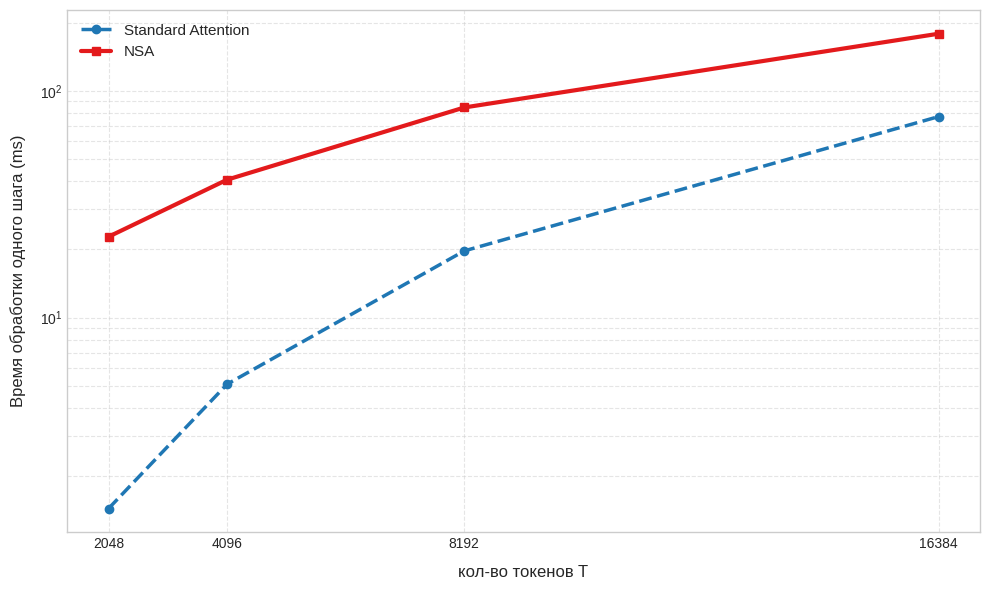

In [ ]:
lengths = [2048, 4096, 8192, 16384]
time_standard = [1.44, 5.09, 19.70, 77.01]
time_nsa = [22.75, 40.60, 84.51, 178.70]

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.figure(figsize=(10, 6))

plt.plot(lengths, time_standard, label='Standard Attention',
         marker='o', linewidth=2.5, color='#1f77b4', linestyle='--')
plt.plot(lengths, time_nsa, label='NSA',
         marker='s', linewidth=3, color='#e31a1c')

#plt.title('Реальный бенчмарк масштабируемости на Tesla T4', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('кол-во токенов T', fontsize=12, labelpad=10)
plt.ylabel('Время обработки одного шага (ms)', fontsize=12, labelpad=10)

plt.xticks(lengths, labels=[str(l) for l in lengths])
plt.yscale('log')

plt.grid(True, linestyle='--', alpha=0.5, which="both")
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()


**Вывод**: Для больших длин по графику заметно, что время выполнения NSA растет гораздо медленее, чем обычного Attetion и точно видна зависимость линейного роста времени у NSA при увеличении длины и квадратичного роста времени Standart Attention.  На длинах порядка 32k или 64k NSA скорее всего станет быстрее обычного Attention. Таким образом, для NSA доказана эффективность.